### Practice, block vs. alternated degree-of-freedom ordering in 3D plate buckling

This notebook compares two strategies for positioning the degrees of freedom (DOFs) inside the global stiffness matrix $\mathbf{K}$ and geometric stiffness matrix $\mathbf{K}_G$ of a 3D plate buckling problem solved with the Ritz method using Legendre polynomial bases.

Both formulations solve the **same physical problem** — the only difference is the order in which the $u$, $v$, $w$ coefficients are stored in the global DOF vector $\mathbf{q}$.

| Strategy | Global DOF vector layout | Index of $u_n$ | Index of $v_n$ | Index of $w_n$ |
|:---|:---|:---:|:---:|:---:|
| **Block** | $[u_1 \cdots u_M \mid v_1 \cdots v_M \mid w_1 \cdots w_M]$ | $n$ | $M + n$ | $2M + n$ |
| **Alternated** | $[u_1, v_1, w_1, \; u_2, v_2, w_2, \; \cdots]$ | $3n$ | $3n + 1$ | $3n + 2$ |

where $M = m_1 \times m_2 \times m_3$ is the number of basis function triplets.

The two orderings are related by a permutation matrix $\mathbf{P}$ such that $\mathbf{q}_\text{alt} = \mathbf{P}\,\mathbf{q}_\text{block}$, and consequently:

$$\mathbf{K}_\text{alt} = \mathbf{P}\,\mathbf{K}_\text{block}\,\mathbf{P}^T, \qquad \mathbf{K}_{G,\text{alt}} = \mathbf{P}\,\mathbf{K}_{G,\text{block}}\,\mathbf{P}^T$$

Since the eigenvalues of a generalized eigenvalue problem are invariant under simultaneous congruence transformation, **both orderings must produce identical eigenvalues**. This notebook verifies that claim and examines how DOF ordering affects sparsity patterns and solver behavior.

#### Import required libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.special import roots_legendre
from scipy.sparse import csc_matrix
from structsolve import lb

from buckling.legendre import vecf, vecfxi

#### Approximation space and quadrature

We define the polynomial expansion orders ($m_1, m_2, m_3$) for the displacement field $(u, v, w)$ along the $x, y, z$ axes. The total degrees of freedom is $N = 3 \times m_1 \times m_2 \times m_3$, and the number of basis function triplets is $M = m_1 \times m_2 \times m_3$.

Integration points and weights are computed using Gauss-Legendre quadrature. The number of integration points ($2m - 1$) is chosen to exactly integrate the stiffness terms formulated by the polynomial bases.

In [16]:
m1 = m2 = 7
m3 = 5
M = m1 * m2 * m3       # DOFs per displacement component
N = 3 * M              # Total DOFs

print(f'm1 = {m1}, m2 = {m2}, m3 = {m3}')
print(f'DOFs per component (M) = {M}')
print(f'Total DOF (N) = {N}')

pts1, weights1 = roots_legendre(2*m1 - 1)
pts2, weights2 = roots_legendre(2*m2 - 1)
pts3, weights3 = roots_legendre(2*m3 - 1)

m1 = 7, m2 = 7, m3 = 5
DOFs per component (M) = 245
Total DOF (N) = 735


#### Material, geometry, and boundary conditions

Isotropic material properties and plate dimensions are defined. A fundamental compressive pre-stress state (`sigxx = -1.0`) is applied to evaluate the geometric stiffness.

Boundary constraints (`xit1`, `xir1`, etc.) are defined to enforce essential boundary conditions directly on the trial functions.

In [17]:
E = 200.0e9
nu = 0.3
G = E / (2 * (1 + nu))

a = 0.3
b = 0.1
h = 0.003

sigxx = -1.0

xit1, xir1 = 0, 1
xit2, xir2 = 0, 1
etat1, etar1 = 0, 1
etat2, etar2 = 0, 1
zetat1, zetar1 = 1, 1
zetat2, zetar2 = 1, 1

#### Pre-allocation and helper functions

Both DOF orderings share the same set of shape-function vectors ($S_u, S_v, S_w$ and their spatial derivatives), stiffness matrices $\mathbf{K}$ and $\mathbf{K}_G$, and the same in-place outer-product helper `addouter`.

The only difference between the two approaches is **where** each coefficient is placed within these length-$N$ vectors — the physics (strain definitions, constitutive law, Jacobian) is identical.

In [18]:
def make_arrays():
    """Allocate fresh working arrays for one assembly pass."""
    Su  = np.zeros(N); Sv  = np.zeros(N); Sw  = np.zeros(N)
    Sux = np.zeros(N); Svx = np.zeros(N); Swx = np.zeros(N)
    Suy = np.zeros(N); Svy = np.zeros(N); Swy = np.zeros(N)
    Suz = np.zeros(N); Svz = np.zeros(N); Swz = np.zeros(N)
    buff = np.zeros((N, N))
    K  = np.zeros((N, N))
    KG = np.zeros((N, N))
    return (Su, Sv, Sw, Sux, Svx, Swx, Suy, Svy, Swy,
            Suz, Svz, Swz, buff, K, KG)

def addouter(matrix, vec1, vec2, buff):
    """In-place addition of outer product to a target matrix."""
    np.outer(vec1, vec2, out=buff)
    matrix += buff

#### DOF ordering: block layout

In the **block** (sequential) ordering, all $u$-coefficients come first, then all $v$-coefficients, then all $w$-coefficients:

$$\mathbf{q}_\text{block} = \bigl[\underbrace{u_1, u_2, \ldots, u_M}_{\text{indices } 0 \ldots M{-}1} \;\big|\; \underbrace{v_1, v_2, \ldots, v_M}_{\text{indices } M \ldots 2M{-}1} \;\big|\; \underbrace{w_1, w_2, \ldots, w_M}_{\text{indices } 2M \ldots 3M{-}1}\bigr]$$

In code, this maps to slice-based indexing:
```python
Su[:M]       = flat   # u-component
Sv[M:2*M]    = flat   # v-component
Sw[2*M:]     = flat   # w-component
```

#### 3D numerical integration — block DOF assembly

The linear stiffness matrix $\mathbf{K}$ and geometric stiffness matrix $\mathbf{K}_G$ are built via numerical integration over the 3D domain using the **block** DOF layout.

In [19]:
(Su, Sv, Sw, Sux, Svx, Swx, Suy, Svy, Swy,
 Suz, Svz, Swz, buff, K_block, KG_block) = make_arrays()

for xi, wxi in zip(pts1, weights1):
    P_xi = vecf(m1, xi, xit1, xir1, xit2, xir2)
    Px_xi = vecfxi(m1, xi, xit1, xir1, xit2, xir2)
    for eta, weta in zip(pts2, weights2):
        P_eta = vecf(m2, eta, etat1, etar1, etat2, etar2)
        Px_eta = vecfxi(m2, eta, etat1, etar1, etat2, etar2)
        for zeta, wzeta in zip(pts3, weights3):
            P_zeta = vecf(m3, zeta, zetat1, zetar1, zetat2, zetar2)
            Px_zeta = vecfxi(m3, zeta, zetat1, zetar1, zetat2, zetar2)
            weight = wxi * weta * wzeta

            # --- Block indexing: Su[:M], Sv[M:2M], Sw[2M:] ---
            Pi, Pj, Pk = np.meshgrid(P_xi, P_eta, P_zeta, indexing='ij')
            flat = (Pi*Pj*Pk).flatten()
            Su[:M] = flat;  Sv[M:2*M] = flat;  Sw[2*M:] = flat

            Pxi, Pj, Pk = np.meshgrid(Px_xi, P_eta, P_zeta, indexing='ij')
            flat_x = (Pxi*Pj*Pk*(2/a)).flatten()
            Sux[:M] = flat_x;  Svx[M:2*M] = flat_x;  Swx[2*M:] = flat_x

            Pi, Pxj, Pk = np.meshgrid(P_xi, Px_eta, P_zeta, indexing='ij')
            flat_y = (Pi*Pxj*Pk*(2/b)).flatten()
            Suy[:M] = flat_y;  Svy[M:2*M] = flat_y;  Swy[2*M:] = flat_y

            Pi, Pj, Pxk = np.meshgrid(P_xi, P_eta, Px_zeta, indexing='ij')
            flat_z = (Pi*Pj*Pxk*(2/h)).flatten()
            Suz[:M] = flat_z;  Svz[M:2*M] = flat_z;  Swz[2*M:] = flat_z

            NL = 0
            exx = Sux + NL*1/2*(Sux**2 + Svx**2 + Swx**2)
            eyy = Svy + NL*1/2*(Suy**2 + Svy**2 + Swy**2)
            ezz = Swz + NL*1/2*(Suz**2 + Svz**2 + Swz**2)
            gxy = Suy + Svx + NL*(Sux*Suy + Svx*Svy + Swx*Swy)
            gxz = Suz + Swx + NL*(Sux*Suz + Svx*Svz + Swx*Swz)
            gyz = Svz + Swy + NL*(Suy*Suz + Svy*Svz + Swy*Swz)

            C = E / ((1 - 2*nu)*(1 + nu))
            Sxx = C * ((1 - nu)*exx + nu*eyy + nu*ezz)
            Syy = C * (nu*exx + (1 - nu)*eyy + nu*ezz)
            Szz = C * (nu*exx + nu*eyy + (1 - nu)*ezz)
            Txy = G * gxy;  Txz = G * gxz;  Tyz = G * gyz

            detJ = a * b * h / 8

            addouter(K_block, detJ*weight*Sxx, exx, buff)
            addouter(K_block, detJ*weight*Syy, eyy, buff)
            addouter(K_block, detJ*weight*Szz, ezz, buff)
            addouter(K_block, detJ*weight*Txy, gxy, buff)
            addouter(K_block, detJ*weight*Txz, gxz, buff)
            addouter(K_block, detJ*weight*Tyz, gyz, buff)

            addouter(KG_block, detJ*weight*sigxx*Swx, Swx, buff)

print('Block assembly done.')

Block assembly done.


#### Eigenvalue solution — block DOF

In [20]:
eigvals_block, eigvecs_block = lb(csc_matrix(K_block), csc_matrix(KG_block),
                                  sparse_solver=False)

D = E * h**3 / (12 * (1 - nu**2))
lbd_block = eigvals_block[0] * sigxx * b**2 * h / np.pi**2 / D

print(f'Block ordering — normalized buckling load: {lbd_block:.6f}')
print(f'First 5 eigenvalues: {eigvals_block[:5]}')

Running linear buckling analysis...
		Eigenvalue solver... 
			Removing null columns...
				360 columns removed
			finished!
			eigh() solver...
			finished!
		finished!
	first 5 eigenvalues:
		1522040927.7001903
		2282698902.6239214
		7425108997.486525
		8109202084.400536
		14777273133.311518
Block ordering — normalized buckling load: -9.355709
First 5 eigenvalues: [1.52204093e+09 2.28269890e+09 7.42510900e+09 8.10920208e+09
 1.47772731e+10]


/opt/miniconda3/lib/python3.13/site-packages/structsolve/linear_buckling.py:79: RuntimeWarning:

divide by zero encountered in divide



#### DOF ordering: alternated (interleaved) layout

In the **alternated** ordering, the three displacement components for each basis triplet $(i, j, k)$ are grouped together:

$$\mathbf{q}_\text{alt} = \bigl[u_1, v_1, w_1, \; u_2, v_2, w_2, \; \ldots, \; u_M, v_M, w_M\bigr]$$

The $n$-th basis triplet maps to global indices $3n$, $3n{+}1$, $3n{+}2$ for $u$, $v$, $w$ respectively. In code, this maps to stride-based indexing:
```python
Su[0::3] = flat   # u-component (every 3rd entry starting at 0)
Sv[1::3] = flat   # v-component (every 3rd entry starting at 1)
Sw[2::3] = flat   # w-component (every 3rd entry starting at 2)
```

This layout is common in finite-element codes where nodal DOFs are kept together for easier application of boundary conditions and contact constraints.

#### 3D numerical integration — alternated DOF assembly

The identical triple Gauss-Legendre loop is executed, but the shape-function vectors are filled using the alternated (interleaved) index mapping. The physics (strain definitions, constitutive law, Jacobian) remain unchanged.

In [21]:
(Su, Sv, Sw, Sux, Svx, Swx, Suy, Svy, Swy,
 Suz, Svz, Swz, buff, K_alt, KG_alt) = make_arrays()

for xi, wxi in zip(pts1, weights1):
    P_xi = vecf(m1, xi, xit1, xir1, xit2, xir2)
    Px_xi = vecfxi(m1, xi, xit1, xir1, xit2, xir2)
    for eta, weta in zip(pts2, weights2):
        P_eta = vecf(m2, eta, etat1, etar1, etat2, etar2)
        Px_eta = vecfxi(m2, eta, etat1, etar1, etat2, etar2)
        for zeta, wzeta in zip(pts3, weights3):
            P_zeta = vecf(m3, zeta, zetat1, zetar1, zetat2, zetar2)
            Px_zeta = vecfxi(m3, zeta, zetat1, zetar1, zetat2, zetar2)
            weight = wxi * weta * wzeta

            # --- Alternated indexing: Su[0::3], Sv[1::3], Sw[2::3] ---
            Pi, Pj, Pk = np.meshgrid(P_xi, P_eta, P_zeta, indexing='ij')
            flat = (Pi*Pj*Pk).flatten()
            Su[0::3] = flat;  Sv[1::3] = flat;  Sw[2::3] = flat

            Pxi, Pj, Pk = np.meshgrid(Px_xi, P_eta, P_zeta, indexing='ij')
            flat_x = (Pxi*Pj*Pk*(2/a)).flatten()
            Sux[0::3] = flat_x;  Svx[1::3] = flat_x;  Swx[2::3] = flat_x

            Pi, Pxj, Pk = np.meshgrid(P_xi, Px_eta, P_zeta, indexing='ij')
            flat_y = (Pi*Pxj*Pk*(2/b)).flatten()
            Suy[0::3] = flat_y;  Svy[1::3] = flat_y;  Swy[2::3] = flat_y

            Pi, Pj, Pxk = np.meshgrid(P_xi, P_eta, Px_zeta, indexing='ij')
            flat_z = (Pi*Pj*Pxk*(2/h)).flatten()
            Suz[0::3] = flat_z;  Svz[1::3] = flat_z;  Swz[2::3] = flat_z

            NL = 0
            exx = Sux + NL*1/2*(Sux**2 + Svx**2 + Swx**2)
            eyy = Svy + NL*1/2*(Suy**2 + Svy**2 + Swy**2)
            ezz = Swz + NL*1/2*(Suz**2 + Svz**2 + Swz**2)
            gxy = Suy + Svx + NL*(Sux*Suy + Svx*Svy + Swx*Swy)
            gxz = Suz + Swx + NL*(Sux*Suz + Svx*Svz + Swx*Swz)
            gyz = Svz + Swy + NL*(Suy*Suz + Svy*Svz + Swy*Swz)

            C = E / ((1 - 2*nu)*(1 + nu))
            Sxx = C * ((1 - nu)*exx + nu*eyy + nu*ezz)
            Syy = C * (nu*exx + (1 - nu)*eyy + nu*ezz)
            Szz = C * (nu*exx + nu*eyy + (1 - nu)*ezz)
            Txy = G * gxy;  Txz = G * gxz;  Tyz = G * gyz

            detJ = a * b * h / 8

            addouter(K_alt, detJ*weight*Sxx, exx, buff)
            addouter(K_alt, detJ*weight*Syy, eyy, buff)
            addouter(K_alt, detJ*weight*Szz, ezz, buff)
            addouter(K_alt, detJ*weight*Txy, gxy, buff)
            addouter(K_alt, detJ*weight*Txz, gxz, buff)
            addouter(K_alt, detJ*weight*Tyz, gyz, buff)

            addouter(KG_alt, detJ*weight*sigxx*Swx, Swx, buff)

print('Alternated assembly done.')

Alternated assembly done.


#### Eigenvalue solution — alternated DOF

In [22]:
eigvals_alt, eigvecs_alt = lb(csc_matrix(K_alt), csc_matrix(KG_alt),
                              sparse_solver=False)

lbd_alt = eigvals_alt[0] * sigxx * b**2 * h / np.pi**2 / D

print(f'Alternated ordering — normalized buckling load: {lbd_alt:.6f}')
print(f'First 5 eigenvalues: {eigvals_alt[:5]}')

Running linear buckling analysis...
		Eigenvalue solver... 
			Removing null columns...
				360 columns removed
			finished!
			eigh() solver...
			finished!
		finished!
	first 5 eigenvalues:
		1522040927.695189
		2282698902.708363
		7425108997.673563
		8109202084.373646
		14777273133.24723
Alternated ordering — normalized buckling load: -9.355709
First 5 eigenvalues: [1.52204093e+09 2.28269890e+09 7.42510900e+09 8.10920208e+09
 1.47772731e+10]


#### Permutation equivalence verification

We now verify that $\mathbf{K}_\text{alt}$ and $\mathbf{K}_\text{block}$ are related by the permutation $\mathbf{P}$ that maps block indices to alternated indices:

$$P(n) = 3n, \quad P(M + n) = 3n + 1, \quad P(2M + n) = 3n + 2 \quad \text{for } n = 0, \ldots, M{-}1$$

If the two systems are truly equivalent, then $\mathbf{K}_\text{block}[\mathbf{P}^{-1}, \mathbf{P}^{-1}] = \mathbf{K}_\text{alt}$ element-wise.

In [23]:
# Build the permutation: perm[block_index] = alternated_index
perm = np.zeros(N, dtype=int)
for n in range(M):
    perm[n]       = 3*n       # u_n
    perm[M + n]   = 3*n + 1   # v_n
    perm[2*M + n] = 3*n + 2   # w_n

inv_perm = np.argsort(perm)
K_permuted  = K_block[np.ix_(inv_perm, inv_perm)]
KG_permuted = KG_block[np.ix_(inv_perm, inv_perm)]

print(f'max|K_permuted  - K_alt|  = {np.max(np.abs(K_permuted - K_alt)):.2e}')
print(f'max|KG_permuted - KG_alt| = {np.max(np.abs(KG_permuted - KG_alt)):.2e}')
print()
print('The matrices are identical under permutation => mathematically equivalent systems.')

max|K_permuted  - K_alt|  = 0.00e+00
max|KG_permuted - KG_alt| = 0.00e+00

The matrices are identical under permutation => mathematically equivalent systems.


#### Matrix properties: rank deficiency

The current boundary condition setup leaves the in-plane directions ($\xi$, $\eta$) free (`xit1=0, xit2=0, etat1=0, etat2=0`), meaning a large number of DOFs are effectively unconstrained. This makes $\mathbf{K}$ severely **rank-deficient** — its null space contains rigid-body-like modes that contribute zero strain energy.

This singularity is the root cause of problems when using iterative sparse eigenvalue solvers.

In [24]:
rank_K  = np.linalg.matrix_rank(K_block)
rank_KG = np.linalg.matrix_rank(KG_block)

print(f'K  rank: {rank_K} / {N}  ({N - rank_K} null DOFs)')
print(f'KG rank: {rank_KG} / {N}')
print(f'\nK is severely rank-deficient: {100*(N - rank_K)/N:.0f}% of DOFs are unconstrained.')
print('This singularity causes problems for iterative sparse eigenvalue solvers.')

K  rank: 375 / 735  (360 null DOFs)
KG rank: 125 / 735

K is severely rank-deficient: 49% of DOFs are unconstrained.
This singularity causes problems for iterative sparse eigenvalue solvers.


#### Sparse solver sensitivity to DOF ordering

The default path in `structsolve.lb` uses `scipy.sparse.linalg.eigsh` with a Cayley shift-invert transform. When $\mathbf{K}$ is singular, `eigsh` raises a `RuntimeError: Factor is exactly singular`, which triggers a fallback path that calls `remove_null_cols` and retries `eigsh` on the reduced (full-rank) system.

However, **even on the reduced system, `eigsh` gives wrong results** due to a poor choice of the shift parameter `sigma`. The generalized eigenvalues of $\mathbf{K}_G \mathbf{x} = \theta \mathbf{K} \mathbf{x}$ are extremely small (order $10^{-10}$), while the hardcoded shift `sigma=1.` is nine orders of magnitude larger. The Cayley transform $\mu = (\theta + \sigma)/(\theta - \sigma)$ with $\sigma = 1$ maps all physical eigenvalues to a cluster near $\mu \approx -1$, so ARPACK's Lanczos iteration cannot distinguish them.

| `sigma` | Block (norm. $\lambda_1$) | Alternated (norm. $\lambda_1$) | Comment |
|:---|:---:|:---:|:---|
| $1$ | $-6.133$ | $-9.068$ | Wrong, ordering-dependent |
| $10^{-1}$ | $-9.357$ | $-9.347$ | Better, small differences |
| $10^{-2}$ | $-9.357$ | $-9.358$ | Close |
| $10^{-4}$ | $-9.356$ | $-9.356$ | Converged |
| $10^{-6}$ | $-9.356$ | $-9.356$ | Matches `eigh` |
| `eigh` | $-9.356$ | $-9.356$ | **Reference (correct)** |

The dense solver `eigh` avoids this issue entirely because it computes **all** eigenvalues via direct factorization (Cholesky + QR/divide-and-conquer), which does not depend on a shift parameter.

**Root cause summary**: the difference between `eigsh` and `eigh` is not about `remove_null_cols` — both paths use it. The problem is that the Cayley shift `sigma=1.` in `structsolve.lb` is inappropriate for problems where the generalized eigenvalues are very small.

In [25]:
def normalize(lam):
    return lam * sigxx * b**2 * h / np.pi**2 / D

# Sparse solver (default eigsh)
eigvals_block_sparse, _ = lb(csc_matrix(K_block), csc_matrix(KG_block), silent=True)
eigvals_alt_sparse, _   = lb(csc_matrix(K_alt), csc_matrix(KG_alt), silent=True)

print(f'{"Solver":<20} {"Block":>12} {"Alternated":>12} {"Match?":>8}')
print('-' * 55)
print(f'{"Sparse (eigsh)":<20} {normalize(eigvals_block_sparse[0]):>12.4f} '
      f'{normalize(eigvals_alt_sparse[0]):>12.4f} '
      f'{"YES" if np.isclose(eigvals_block_sparse[0], eigvals_alt_sparse[0], rtol=1e-6) else "NO":>8}')
print(f'{"Dense (eigh)":<20} {normalize(eigvals_block[0]):>12.4f} '
      f'{normalize(eigvals_alt[0]):>12.4f} '
      f'{"YES" if np.isclose(eigvals_block[0], eigvals_alt[0], rtol=1e-6) else "NO":>8}')

print(f'\nFirst 5 eigenvalues — sparse solver:')
print(f'  Block:      {eigvals_block_sparse[:5]}')
print(f'  Alternated: {eigvals_alt_sparse[:5]}')

print(f'\nFirst 5 eigenvalues — dense solver:')
print(f'  Block:      {eigvals_block[:5]}')
print(f'  Alternated: {eigvals_alt[:5]}')

Solver                      Block   Alternated   Match?
-------------------------------------------------------
Sparse (eigsh)            -4.5133      -9.2608       NO
Dense (eigh)              -9.3557      -9.3557      YES

First 5 eigenvalues — sparse solver:
  Block:      [7.34243500e+08 1.87060879e+09 2.66065816e+09 4.85404597e+09
 6.36682570e+09]
  Alternated: [1.50660507e+09 2.28737536e+09 6.71350132e+09 7.08758386e+09
 9.07243459e+09]

First 5 eigenvalues — dense solver:
  Block:      [1.52204093e+09 2.28269890e+09 7.42510900e+09 8.10920208e+09
 1.47772731e+10]
  Alternated: [1.52204093e+09 2.28269890e+09 7.42510900e+09 8.10920208e+09
 1.47772731e+10]


#### Comparison of stiffness matrix sparsity patterns

Although the two systems have the same eigenvalues, their **sparsity patterns** differ dramatically. The block ordering produces a characteristic $3 \times 3$ block structure with three dense diagonal blocks ($\mathbf{K}_{uu}$, $\mathbf{K}_{vv}$, $\mathbf{K}_{ww}$) and off-diagonal coupling blocks. The alternated ordering distributes the non-zeros more uniformly, producing a banded or semi-banded pattern.

These structural differences affect:
- **Memory layout**: block ordering is more cache-friendly during assembly since consecutive DOFs often share the same basis function type.
- **Sparse storage**: CSC/CSR compression ratios differ between the two patterns.
- **Iterative solvers**: preconditioner effectiveness and convergence rates depend on the bandwidth and clustering of non-zeros.

Non-zeros (block):      71915 (13.3%)
Non-zeros (alternated): 71915 (13.3%)


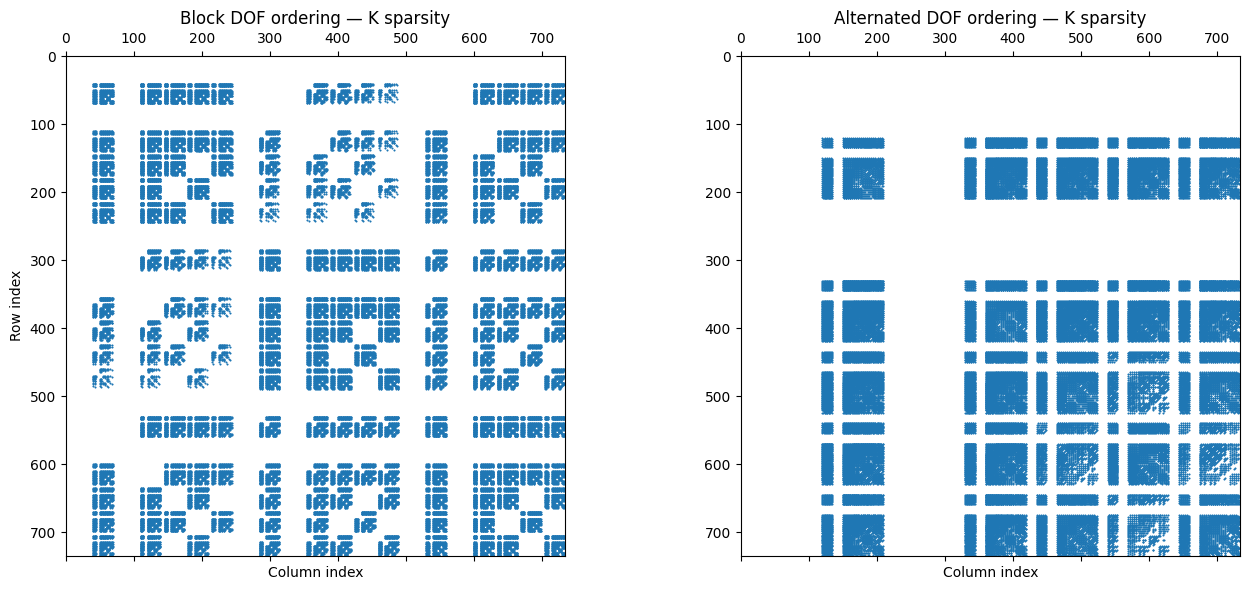

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

thr = 1e-6 * np.max(np.abs(K_block))

axes[0].spy(np.abs(K_block) > thr, markersize=0.5, aspect='equal')
axes[0].set_title('Block DOF ordering — K sparsity')
axes[0].set_xlabel('Column index')
axes[0].set_ylabel('Row index')

axes[1].spy(np.abs(K_alt) > thr, markersize=0.5, aspect='equal')
axes[1].set_title('Alternated DOF ordering — K sparsity')
axes[1].set_xlabel('Column index')

nnz_block = np.count_nonzero(np.abs(K_block) > thr)
nnz_alt   = np.count_nonzero(np.abs(K_alt) > thr)
print(f'Non-zeros (block):      {nnz_block} ({100*nnz_block/N**2:.1f}%)')
print(f'Non-zeros (alternated): {nnz_alt} ({100*nnz_alt/N**2:.1f}%)')

plt.tight_layout()
plt.show()
#fig.savefig('BasicPrinciples-DOF-ordering-sparsity.pdf', bbox_inches='tight')
#fig.savefig('BasicPrinciples-DOF-ordering-sparsity.jpg', bbox_inches='tight')


#### Comparison of eigenvalues

The table below confirms that the dense solver produces identical eigenvalues for both orderings — as expected from the permutation equivalence proven above. Any difference between the two is due to floating-point arithmetic in the assembly loop, on the order of machine precision.

In [27]:
n_compare = min(10, len(eigvals_block))
print(f'{"Mode":<6} {"Block":>18} {"Alternated":>18} {"Rel. diff":>12}')
print('-' * 56)
for i in range(n_compare):
    rel = abs(eigvals_block[i] - eigvals_alt[i]) / abs(eigvals_block[i]) if eigvals_block[i] != 0 else 0
    print(f'{i+1:<6} {eigvals_block[i]:>18.6e} {eigvals_alt[i]:>18.6e} {rel:>12.2e}')

Mode                Block         Alternated    Rel. diff
--------------------------------------------------------
1            1.522041e+09       1.522041e+09     3.29e-12
2            2.282699e+09       2.282699e+09     3.70e-11
3            7.425109e+09       7.425109e+09     2.52e-11
4            8.109202e+09       8.109202e+09     3.32e-12
5            1.477727e+10       1.477727e+10     4.35e-12
6            2.864875e+10       2.864875e+10     1.58e-12
7            3.956282e+10       3.956282e+10     6.17e-12
8            4.235453e+10       4.235453e+10     8.24e-12
9            4.476558e+10       4.476558e+10     3.55e-12
10           4.895995e+10       4.895995e+10     9.32e-11


#### 3D visualization of buckling mode shapes

The eigenvector coefficients are extracted differently depending on the DOF ordering:

| DOF ordering | $u$-coefficients | $v$-coefficients | $w$-coefficients |
|:---|:---|:---|:---|
| Block | `eigvecs[0:M, mode]` | `eigvecs[M:2M, mode]` | `eigvecs[2M:3M, mode]` |
| Alternated | `eigvecs[0::3, mode]` | `eigvecs[1::3, mode]` | `eigvecs[2::3, mode]` |

Once extracted, each coefficient vector is reshaped into a $(m_1, m_2, m_3)$ tensor and contracted with the 1D basis evaluation matrices via `np.einsum` to reconstruct the 3D displacement field.

The visualization below uses the **block** ordering eigenvectors.

In [28]:
num_modes = 3
scale = 100

nx, ny, nz = 40, 20, 3
x_1d = np.linspace(0, a, nx)
y_1d = np.linspace(0, b, ny)
z_1d = np.linspace(-h/2, h/2, nz)

xi_1d   = 2 * x_1d / a - 1
eta_1d  = 2 * y_1d / b - 1
zeta_1d = 2 * z_1d / h - 1

P_xi   = np.array([vecf(m1, xi, xit1, xir1, xit2, xir2) for xi in xi_1d])
P_eta  = np.array([vecf(m2, eta, etat1, etar1, etat2, etar2) for eta in eta_1d])
P_zeta = np.array([vecf(m3, zeta, zetat1, zetar1, zetat2, zetar2) for zeta in zeta_1d])

U_field = np.zeros((num_modes, nx, ny, nz))
V_field = np.zeros((num_modes, nx, ny, nz))
W_field = np.zeros((num_modes, nx, ny, nz))

for mode in range(num_modes):
    # Block ordering: [u | v | w]
    c_U = eigvecs_block[0:M, mode].reshape((m1, m2, m3))
    c_V = eigvecs_block[M:2*M, mode].reshape((m1, m2, m3))
    c_W = eigvecs_block[2*M:3*M, mode].reshape((m1, m2, m3))

    U_field[mode] = np.einsum('ijk, xi, yj, zk -> xyz', c_U, P_xi, P_eta, P_zeta)
    V_field[mode] = np.einsum('ijk, xi, yj, zk -> xyz', c_V, P_xi, P_eta, P_zeta)
    W_field[mode] = np.einsum('ijk, xi, yj, zk -> xyz', c_W, P_xi, P_eta, P_zeta)

X, Y, Z = np.meshgrid(x_1d, y_1d, z_1d, indexing='ij')

fig = go.Figure()
for mode in range(num_modes):
    X_def = X + scale * U_field[mode]
    Y_def = Y + scale * V_field[mode]
    Z_def = Z + scale * W_field[mode]
    W_amp = W_field[mode]

    lines_x, lines_y, lines_z, lines_w = [], [], [], []
    for j in range(ny):
        for k in range(nz):
            lines_x.extend(X_def[:, j, k].tolist() + [None])
            lines_y.extend(Y_def[:, j, k].tolist() + [None])
            lines_z.extend(Z_def[:, j, k].tolist() + [None])
            lines_w.extend(W_amp[:, j, k].tolist() + [0.0])
    for i in range(nx):
        for k in range(nz):
            lines_x.extend(X_def[i, :, k].tolist() + [None])
            lines_y.extend(Y_def[i, :, k].tolist() + [None])
            lines_z.extend(Z_def[i, :, k].tolist() + [None])
            lines_w.extend(W_amp[i, :, k].tolist() + [0.0])
    for i in range(nx):
        for j in range(ny):
            lines_x.extend(X_def[i, j, :].tolist() + [None])
            lines_y.extend(Y_def[i, j, :].tolist() + [None])
            lines_z.extend(Z_def[i, j, :].tolist() + [None])
            lines_w.extend(W_amp[i, j, :].tolist() + [0.0])

    fig.add_trace(go.Scatter3d(
        x=lines_x, y=lines_y, z=lines_z, mode='lines',
        line=dict(color=lines_w, colorscale='Jet', width=3,
                  showscale=True, colorbar=dict(title=f'W (Mode {mode+1})', x=0.85)),
        name=f'Mode {mode+1}', opacity=0.9, visible=(mode == 0)
    ))

buttons = []
for mode in range(num_modes):
    vis = [False] * num_modes
    vis[mode] = True
    buttons.append(dict(label=f'Mode {mode+1}', method='update',
                        args=[{'visible': vis},
                              {'title': f'Buckling Mode Shape: Mode {mode+1}'}]))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=0.05, xanchor='left',
                      y=1.05, yanchor='top', direction='down', showactive=True)],
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='data'),
    title='Buckling Mode Shape: Mode 1', showlegend=False,
    margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()

#### Conclusion

**Block** and **alternated** DOF orderings produce stiffness matrices that are identical up to a permutation. The eigenvalue spectrum is therefore invariant — the physics does not depend on how array indices are assigned.

However, DOF ordering has important **numerical** consequences:

1. **Sparsity pattern**: block ordering yields a block-structured matrix; alternated ordering yields a banded pattern. These affect sparse storage efficiency, preconditioner design, and fill-in during factorization.

2. **Sparse solver sensitivity**: `structsolve.lb` with `sparse_solver=True` first tries `eigsh` on the raw system. When $\mathbf{K}$ is singular (as here), the `RuntimeError: Factor is exactly singular` is caught and the fallback path calls `remove_null_cols` before retrying `eigsh`. However, **`eigsh` still gives wrong results on the reduced full-rank system** because the hardcoded Cayley shift `sigma=1.` is inappropriate — the generalized eigenvalues are of order $10^{-10}$, so the Cayley transform $\mu = (\theta + \sigma)/(\theta - \sigma)$ with $\sigma = 1$ clusters all eigenvalues near $\mu \approx -1$, making them indistinguishable for ARPACK's Lanczos iteration. The DOF ordering changes the sparsity pattern, which changes the internal LU pivoting, producing **different wrong eigenvalues** for each ordering.

3. **`eigh` robustness**: the dense solver `eigh` computes all eigenvalues via direct factorization without a shift parameter, giving correct and consistent results regardless of DOF ordering.

4. **Remedies**:
    - Use `sparse_solver=False` in `structsolve.lb` to use the dense `eigh` solver.
    - Alternatively, fix the `sigma` value in the sparse path to be close to the expected eigenvalue magnitude (e.g., `sigma=1e-6` instead of `sigma=1.` for this problem).

### Block vs. Alternated Degree-of-Freedom Ordering in 3D Plate Buckling

This notebook compares two strategies for positioning the degrees of freedom (DOFs) inside the global stiffness matrix $\mathbf{K}$ and geometric stiffness matrix $\mathbf{K}_G$ of a 3D plate buckling problem solved with the Ritz method using Legendre polynomial bases.

Both formulations solve the **same physical problem** — the only difference is the order in which the $u$, $v$, $w$ coefficients are stored in the global DOF vector $\mathbf{q}$.

| Strategy | Global DOF vector layout | Index of $u_n$ | Index of $v_n$ | Index of $w_n$ |
|:---|:---|:---:|:---:|:---:|
| **Block** | $[u_1 \cdots u_M \mid v_1 \cdots v_M \mid w_1 \cdots w_M]$ | $n$ | $M + n$ | $2M + n$ |
| **Alternated** | $[u_1, v_1, w_1, \; u_2, v_2, w_2, \; \cdots]$ | $3n$ | $3n + 1$ | $3n + 2$ |

where $M = m_1 \times m_2 \times m_3$ is the number of basis function triplets.

The two orderings are related by a permutation matrix $\mathbf{P}$ such that $\mathbf{q}_\text{alt} = \mathbf{P}\,\mathbf{q}_\text{block}$, and consequently:

$$\mathbf{K}_\text{alt} = \mathbf{P}\,\mathbf{K}_\text{block}\,\mathbf{P}^T, \qquad \mathbf{K}_{G,\text{alt}} = \mathbf{P}\,\mathbf{K}_{G,\text{block}}\,\mathbf{P}^T$$

Since the eigenvalues of a generalized eigenvalue problem are invariant under simultaneous congruence transformation, **both orderings must produce identical eigenvalues**. This notebook verifies that claim and examines how DOF ordering affects sparsity patterns and solver behavior.